# Taller 2 — Sistema de Recomendación Híbrido Yelp


Este notebook implementa un recomendador híbrido que combina filtrado colaborativo por factorización matricial (`TruncatedSVD`) y recomendación sensible al contexto. Incluye evaluación offline, sintonización del peso híbrido, recomendaciones explicables y generación de una app básica en Streamlit.


In [ ]:
# ============================================================
# 0. IMPORTAR LIBRERÍAS
# ============================================================

import os
import json
import math
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Configuración de rutas


In [ ]:
# ============================================================
# 1. CONFIGURACIÓN DE RUTAS
# ============================================================

DATA_DIR = Path("/Users/andres/sis_reco/Taller2/Yelp_JSON/yelp_dataset")
PHOTOS_DIR = Path("/Users/andres/sis_reco/Taller2/Yelp_Photos/yelp_photos")

REVIEW_FILE = DATA_DIR / "yelp_academic_dataset_review.json"
BUSINESS_FILE = DATA_DIR / "yelp_academic_dataset_business.json"
USER_FILE = DATA_DIR / "yelp_academic_dataset_user.json"
PHOTOS_FILE = PHOTOS_DIR / "photos.json"

print("Review existe:", REVIEW_FILE.exists(), REVIEW_FILE)
print("Business existe:", BUSINESS_FILE.exists(), BUSINESS_FILE)
print("User existe:", USER_FILE.exists(), USER_FILE)
print("Photos existe:", PHOTOS_FILE.exists(), PHOTOS_FILE)

Review existe: True /Users/andres/sis_reco/Taller2/Yelp_JSON/yelp_dataset/yelp_academic_dataset_review.json
Business existe: True /Users/andres/sis_reco/Taller2/Yelp_JSON/yelp_dataset/yelp_academic_dataset_business.json
User existe: True /Users/andres/sis_reco/Taller2/Yelp_JSON/yelp_dataset/yelp_academic_dataset_user.json
Photos existe: True /Users/andres/sis_reco/Taller2/Yelp_Photos/yelp_photos/photos.json


## 2. Parámetros de ejecución

Para pruebas rápidas se usa entre 50.000 y 100.000 reviews.

In [ ]:
# ============================================================
# 2. PARÁMETROS
# ============================================================

MAX_REVIEWS = 100_000
MIN_USER_REVIEWS = 3
MIN_BUSINESS_REVIEWS = 3

N_FACTORS = 30
TEST_SIZE = 0.20

TOP_K = 10
MIN_ALPHA_HYBRID = 0.10   # Evita que el híbrido ignore completamente el SVD
MAX_ALPHA_HYBRID = 0.90

OUTPUT_DIR = Path("./entrega_taller2")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Parámetros definidos")

Parámetros definidos


## 3. Función para cargar JSONL

In [ ]:
# ============================================================
# 3. FUNCIÓN PARA CARGAR JSON LINE BY LINE
# ============================================================

def load_json_lines(path, max_rows=None, columns=None):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, desc=f"Cargando {Path(path).name}")):
            if max_rows is not None and i >= max_rows:
                break
            row = json.loads(line)
            if columns is not None:
                row = {col: row.get(col) for col in columns}
            records.append(row)
    return pd.DataFrame(records)

## 4. Carga de datos

In [ ]:
# ============================================================
# 4. CARGAR REVIEWS Y NEGOCIOS
# ============================================================

review_cols = ["review_id", "user_id", "business_id", "stars", "date", "text"]
business_cols = ["business_id", "name", "city", "state", "latitude", "longitude", "stars", "review_count", "categories"]

reviews = load_json_lines(REVIEW_FILE, max_rows=MAX_REVIEWS, columns=review_cols)
business = load_json_lines(BUSINESS_FILE, max_rows=None, columns=business_cols)

print("Reviews:", reviews.shape)
print("Business:", business.shape)

display(reviews.head())
display(business.head())

Cargando yelp_academic_dataset_review.json: 100000it [00:00, 352409.51it/s]
Cargando yelp_academic_dataset_business.json: 150346it [00:00, 263034.40it/s]


Reviews: (100000, 6)
Business: (150346, 9)


,review_id,user_id,business_id,stars,date,text
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,2018-07-07 22:09:11,"If you decide to eat here, just be aware it is..."
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,2012-01-03 15:28:18,I've taken a lot of spin classes over the year...
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,2014-02-05 20:30:30,Family diner. Had the buffet. Eclectic assortm...
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,2015-01-04 00:01:03,"Wow! Yummy, different, delicious. Our favo..."
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,2017-01-14 20:54:15,Cute interior and owner (?) gave us tour of up...


,business_id,name,city,state,latitude,longitude,stars,review_count,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ",Santa Barbara,CA,34.426679,-119.711197,5.0,7,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,Affton,MO,38.551126,-90.335695,3.0,15,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,Tucson,AZ,32.223236,-110.880452,3.5,22,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,39.955505,-75.155564,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,Green Lane,PA,40.338183,-75.471659,4.5,13,"Brewpubs, Breweries, Food"


## 5. Limpieza, unión y variables contextuales

In [ ]:
# ============================================================
# 5. LIMPIEZA Y UNIÓN
# ============================================================

reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
reviews = reviews.dropna(subset=["user_id", "business_id", "stars", "date"]).copy()
reviews["stars"] = reviews["stars"].astype(float)

business = business.rename(columns={"stars": "business_avg_stars"}).copy()
business["categories"] = business["categories"].fillna("Unknown")
business["main_category"] = business["categories"].apply(lambda x: str(x).split(",")[0].strip())

df = reviews.merge(business, on="business_id", how="inner")

df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

model_cols = [
    "user_id", "business_id", "stars", "date", "city", "state", "latitude", "longitude",
    "name", "main_category", "business_avg_stars", "review_count", "is_weekend", "year", "month"
]
df_model = df[model_cols].dropna(subset=["user_id", "business_id", "stars", "city", "main_category"]).copy()

print("Dataset unido:", df_model.shape)
display(df_model.head())

Dataset unido: (100000, 15)


,user_id,business_id,stars,date,city,state,latitude,longitude,name,main_category,business_avg_stars,review_count,is_weekend,year,month
0,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,2018-07-07 22:09:11,North Wales,PA,40.210196,-75.223639,Turning Point of North Wales,Restaurants,3.0,169,1,2018,7
1,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,2012-01-03 15:28:18,Philadelphia,PA,39.952103,-75.172753,Body Cycle Spinning Studio,Active Life,5.0,144,0,2012,1
2,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,2014-02-05 20:30:30,Tucson,AZ,32.207233,-110.980864,Kettle Restaurant,Restaurants,3.5,47,0,2014,2
3,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,2015-01-04 00:01:03,Philadelphia,PA,40.079848,-75.025080,Zaika,Halal,4.0,181,1,2015,1
4,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,2017-01-14 20:54:15,New Orleans,LA,29.962102,-90.087958,Melt,Sandwiches,4.0,32,1,2017,1


## 6. Filtrado mínimo de usuarios y negocios

In [ ]:
# ============================================================
# 6. FILTRADO DE INTERACCIONES MÍNIMAS
# ============================================================

user_counts = df_model["user_id"].value_counts()
business_counts = df_model["business_id"].value_counts()

valid_users = user_counts[user_counts >= MIN_USER_REVIEWS].index
valid_business = business_counts[business_counts >= MIN_BUSINESS_REVIEWS].index

df_model = df_model[
    df_model["user_id"].isin(valid_users) &
    df_model["business_id"].isin(valid_business)
].copy()

print("Dataset después del filtro:", df_model.shape)
print("Usuarios únicos:", df_model["user_id"].nunique())
print("Negocios únicos:", df_model["business_id"].nunique())
print("Rating promedio:", round(df_model["stars"].mean(), 4))

Dataset después del filtro: (15634, 15)
Usuarios únicos: 3828
Negocios únicos: 3921
Rating promedio: 3.8407


## 7. División Train / Test

La división se hace antes de entrenar el SVD y antes de calcular estadísticas contextuales. Evitando la fuga de información.

In [ ]:
# ============================================================
# 7. TRAIN / TEST
# ============================================================

train_df, test_df = train_test_split(
    df_model,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_df = train_df.copy()
test_df = test_df.copy()

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (12507, 15)
Test: (3127, 15)


## 8. Modelo colaborativo por factorización matricial: SVD

Se entrena `TruncatedSVD` únicamente con `train_df`. La matriz usuario-item se representa como matriz dispersa.

In [ ]:
# ============================================================
# 8. ENTRENAR SVD CON SKLEARN SOBRE TRAIN
# ============================================================

global_mean = train_df["stars"].mean()
user_mean = train_df.groupby("user_id")["stars"].mean().to_dict()
business_mean = train_df.groupby("business_id")["stars"].mean().to_dict()

train_users = sorted(train_df["user_id"].unique())
train_items = sorted(train_df["business_id"].unique())

user_to_idx = {u: i for i, u in enumerate(train_users)}
item_to_idx = {b: i for i, b in enumerate(train_items)}
idx_to_user = {i: u for u, i in user_to_idx.items()}
idx_to_item = {i: b for b, i in item_to_idx.items()}

rows = train_df["user_id"].map(user_to_idx).values
cols = train_df["business_id"].map(item_to_idx).values
values = train_df["stars"].values

ratings_sparse = csr_matrix((values, (rows, cols)), shape=(len(train_users), len(train_items)))

n_components = min(N_FACTORS, ratings_sparse.shape[0] - 1, ratings_sparse.shape[1] - 1)
print("Factores SVD usados:", n_components)

svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
user_factors = svd.fit_transform(ratings_sparse)
item_factors = svd.components_.T

print("SVD entrenado")
print("User factors:", user_factors.shape)
print("Item factors:", item_factors.shape)
print("Varianza explicada acumulada:", round(svd.explained_variance_ratio_.sum(), 4))

Factores SVD usados: 30
SVD entrenado
User factors: (3795, 30)
Item factors: (3593, 30)
Varianza explicada acumulada: 0.11


## 9. Predicción SVD

In [ ]:
# ============================================================
# 9. FUNCIONES DE PREDICCIÓN SVD
# ============================================================

def baseline_prediction(user_id, business_id):
    if user_id in user_mean and business_id in business_mean:
        return (user_mean[user_id] + business_mean[business_id]) / 2
    if user_id in user_mean:
        return user_mean[user_id]
    if business_id in business_mean:
        return business_mean[business_id]
    return global_mean


def predict_svd(user_id, business_id):
    if user_id in user_to_idx and business_id in item_to_idx:
        u_idx = user_to_idx[user_id]
        i_idx = item_to_idx[business_id]
        pred = float(np.dot(user_factors[u_idx], item_factors[i_idx]))
    else:
        pred = baseline_prediction(user_id, business_id)
    return float(np.clip(pred, 1, 5))


test_df["pred_svd"] = [predict_svd(u, b) for u, b in zip(test_df["user_id"], test_df["business_id"])]
display(test_df[["user_id", "business_id", "stars", "pred_svd"]].head())

,user_id,business_id,stars,pred_svd
97441,3Zl3RokY8eyRJQbbQmuOuA,7lwe7n-Yc-V9E_HfLAeylg,3.0,1.000000
56916,__QLyY_W06q10ZfBQg7Dcg,CLEWowfkj-wKYJlQDqT1aw,4.0,4.333333
35356,gpqGjIHlvUKDTttna4wcZQ,IOroNIZhOtGM9nWMT3PaNA,2.0,1.000000
56087,yA7KZuswD0f_udzYIO-GHQ,AWJyivVwe3t9BO-k8D0ynQ,4.0,1.000000
65095,DDJliZbj8VYfwikMQWbrBA,FsRAHiYUERqUIeGVt49svA,4.0,1.000000


## 10. Modelo sensible al contexto

El score contextual se calcula con estadísticas de entrenamiento usando ciudad, categoría principal e indicador de fin de semana.

In [ ]:
# ============================================================
# 10. MODELO CONTEXTUAL ENTRENADO SOLO CON TRAIN
# ============================================================

context_stats = (
    train_df
    .groupby(["city", "main_category", "is_weekend"], as_index=False)
    .agg(context_score=("stars", "mean"), context_count=("stars", "size"))
)

category_stats = train_df.groupby("main_category")["stars"].mean().to_dict()
city_stats = train_df.groupby("city")["stars"].mean().to_dict()


def predict_context(row):
    city = row["city"]
    cat = row["main_category"]
    weekend = row["is_weekend"]

    match = context_stats[
        (context_stats["city"] == city) &
        (context_stats["main_category"] == cat) &
        (context_stats["is_weekend"] == weekend)
    ]
    if len(match) > 0:
        return float(match["context_score"].iloc[0])
    if cat in category_stats:
        return float(category_stats[cat])
    if city in city_stats:
        return float(city_stats[city])
    return float(global_mean)


test_df["pred_context"] = test_df.apply(predict_context, axis=1)

print("Context stats:", context_stats.shape)
display(context_stats.sort_values("context_count", ascending=False).head())
display(test_df[["stars", "pred_svd", "pred_context"]].head())

Context stats: (3126, 5)


,city,main_category,is_weekend,context_score,context_count
1878,Philadelphia,Restaurants,0,3.891089,505
1879,Philadelphia,Restaurants,1,3.715152,165
1745,Philadelphia,Food,0,3.778481,158
1677,Philadelphia,Bars,0,3.728155,103
2933,Tucson,Restaurants,0,3.553191,94


,stars,pred_svd,pred_context
97441,3.0,1.000000,3.715152
56916,4.0,4.333333,4.230769
35356,2.0,1.000000,1.000000
56087,4.0,1.000000,4.115385
65095,4.0,1.000000,3.891089


## 11. Evaluación de modelos base

In [ ]:
# ============================================================
# 11. EVALUACIÓN RMSE Y MAE
# ============================================================

def evaluate_regression(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"modelo": model_name, "RMSE": rmse, "MAE": mae}

results = []
results.append(evaluate_regression(test_df["stars"], test_df["pred_svd"], "SVD - Factorización"))
results.append(evaluate_regression(test_df["stars"], test_df["pred_context"], "Modelo contextual"))

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

,modelo,RMSE,MAE
1,Modelo contextual,1.141471,0.882366
0,SVD - Factorización,2.883657,2.611238


## 12. Sintonización del modelo híbrido

`score_hybrid = alpha * pred_svd + (1 - alpha) * pred_context`. Se restringe `alpha` entre 0.10 y 0.90 para mantener ambos componentes activos.

In [ ]:
# ============================================================
# 12. SINTONIZACIÓN DEL PESO ALPHA
# ============================================================

hybrid_results = []

for alpha in np.arange(0.0, 1.01, 0.05):
    pred = alpha * test_df["pred_svd"] + (1 - alpha) * test_df["pred_context"]
    pred = np.clip(pred, 1, 5)
    rmse = np.sqrt(mean_squared_error(test_df["stars"], pred))
    mae = mean_absolute_error(test_df["stars"], pred)
    hybrid_results.append({
        "alpha_svd": round(alpha, 2),
        "alpha_context": round(1 - alpha, 2),
        "RMSE": rmse,
        "MAE": mae
    })

hybrid_results_df = pd.DataFrame(hybrid_results).sort_values("RMSE")

print("Mejores combinaciones del rango completo:")
display(hybrid_results_df.head(10))

constrained = hybrid_results_df[
    (hybrid_results_df["alpha_svd"] >= MIN_ALPHA_HYBRID) &
    (hybrid_results_df["alpha_svd"] <= MAX_ALPHA_HYBRID)
].copy()

best_alpha = float(constrained.iloc[0]["alpha_svd"])

print("Mejor alpha híbrido restringido para SVD:", best_alpha)
print("Peso contexto:", round(1 - best_alpha, 2))

test_df["pred_hybrid"] = np.clip(best_alpha * test_df["pred_svd"] + (1 - best_alpha) * test_df["pred_context"], 1, 5)

results.append(evaluate_regression(test_df["stars"], test_df["pred_hybrid"], "Modelo híbrido SVD + Contexto"))
final_results_df = pd.DataFrame(results).sort_values("RMSE")
display(final_results_df)

Mejores combinaciones del rango completo:


,alpha_svd,alpha_context,RMSE,MAE
0,0.00,1.00,1.141471,0.882366
1,0.05,0.95,1.144154,0.908105
2,0.10,0.90,1.162533,0.942241
3,0.15,0.85,1.195885,0.985456
4,0.20,0.80,1.243004,1.035816
5,0.25,0.75,1.302398,1.092016
6,0.30,0.70,1.372475,1.161313
7,0.35,0.65,1.451686,1.241618
8,0.40,0.60,1.538624,1.330415
9,0.45,0.55,1.632053,1.423175


Mejor alpha híbrido restringido para SVD: 0.1
Peso contexto: 0.9


,modelo,RMSE,MAE
1,Modelo contextual,1.141471,0.882366
2,Modelo híbrido SVD + Contexto,1.162533,0.942241
0,SVD - Factorización,2.883657,2.611238


## 13. Gráfica RMSE vs alpha

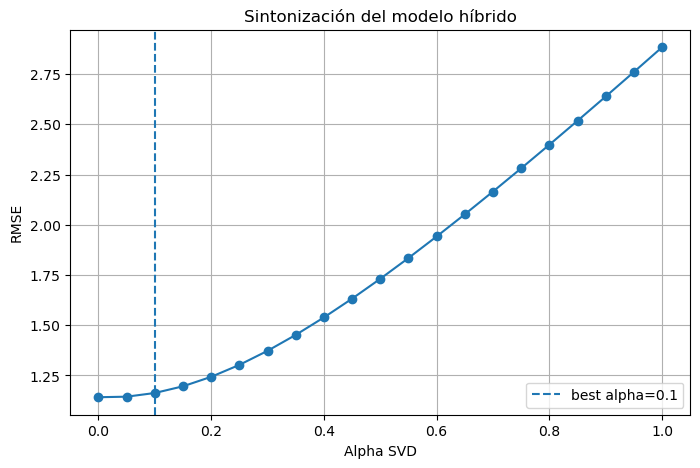

In [ ]:
# ============================================================
# 13. GRÁFICA RMSE VS ALPHA
# ============================================================

alpha_plot = hybrid_results_df.sort_values("alpha_svd")
plt.figure(figsize=(8, 5))
plt.plot(alpha_plot["alpha_svd"], alpha_plot["RMSE"], marker="o")
plt.axvline(best_alpha, linestyle="--", label=f"best alpha={best_alpha}")
plt.xlabel("Alpha SVD")
plt.ylabel("RMSE")
plt.title("Sintonización del modelo híbrido")
plt.legend()
plt.grid(True)
plt.show()

## 14. Métricas de ranking: Precision@K, Recall@K y NDCG@K

In [ ]:
# ============================================================
# 14. MÉTRICAS TOP-K
# ============================================================

def dcg_at_k(relevances, k):
    relevances = np.asarray(relevances)[:k]
    if relevances.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, relevances.size + 2))
    return np.sum(relevances / discounts)


def ndcg_at_k(relevances, k):
    dcg = dcg_at_k(relevances, k)
    ideal = dcg_at_k(sorted(relevances, reverse=True), k)
    return dcg / ideal if ideal > 0 else 0.0


def ranking_metrics(df_eval, pred_col="pred_hybrid", k=10, relevance_threshold=4.0):
    metrics = []
    for user_id, group in df_eval.groupby("user_id"):
        group = group.sort_values(pred_col, ascending=False).copy()
        group["relevant"] = (group["stars"] >= relevance_threshold).astype(int)
        top_k = group.head(k)
        n_relevant_user = group["relevant"].sum()
        precision = top_k["relevant"].sum() / k
        recall = top_k["relevant"].sum() / n_relevant_user if n_relevant_user > 0 else np.nan
        ndcg = ndcg_at_k(top_k["relevant"].tolist(), k)
        metrics.append({"user_id": user_id, f"precision@{k}": precision, f"recall@{k}": recall, f"ndcg@{k}": ndcg})
    return pd.DataFrame(metrics)

rank_svd = ranking_metrics(test_df, "pred_svd", k=TOP_K)
rank_context = ranking_metrics(test_df, "pred_context", k=TOP_K)
rank_hybrid = ranking_metrics(test_df, "pred_hybrid", k=TOP_K)

ranking_summary = pd.DataFrame([
    {"modelo": "SVD - Factorización", **rank_svd.drop(columns="user_id").mean(numeric_only=True).to_dict()},
    {"modelo": "Modelo contextual", **rank_context.drop(columns="user_id").mean(numeric_only=True).to_dict()},
    {"modelo": "Modelo híbrido SVD + Contexto", **rank_hybrid.drop(columns="user_id").mean(numeric_only=True).to_dict()},
])

display(ranking_summary)

,modelo,precision@10,recall@10,ndcg@10
0,SVD - Factorización,0.101577,0.999781,0.742006
1,Modelo contextual,0.101577,0.999781,0.747643
2,Modelo híbrido SVD + Contexto,0.101623,0.999836,0.747665


## 15. Función de recomendación explicable

In [ ]:
# ============================================================
# 15. FUNCIÓN DE RECOMENDACIÓN
# ============================================================

item_features = (
    df_model[["business_id", "name", "city", "state", "main_category", "business_avg_stars", "review_count"]]
    .drop_duplicates("business_id")
    .copy()
)


def recommend_for_user(user_id, city=None, main_category=None, is_weekend=0, top_n=10):
    """Recomienda negocios no calificados por el usuario usando SVD + contexto."""

    seen_items = set(df_model.loc[df_model["user_id"] == user_id, "business_id"].unique())
    candidates = item_features[~item_features["business_id"].isin(seen_items)].copy()

    if city is not None:
        candidates = candidates[candidates["city"].str.lower() == city.lower()].copy()
    if main_category is not None:
        candidates = candidates[candidates["main_category"].str.lower() == main_category.lower()].copy()
    if candidates.empty:
        return pd.DataFrame()

    candidates["is_weekend"] = is_weekend
    candidates["pred_svd"] = [predict_svd(user_id, b) for b in candidates["business_id"]]

    candidates = candidates.merge(
        context_stats[["city", "main_category", "is_weekend", "context_score", "context_count"]],
        on=["city", "main_category", "is_weekend"],
        how="left"
    )
    candidates["pred_context"] = candidates["context_score"].fillna(global_mean)
    candidates["context_count"] = candidates["context_count"].fillna(0).astype(int)

    candidates["score_hybrid"] = np.clip(best_alpha * candidates["pred_svd"] + (1 - best_alpha) * candidates["pred_context"], 1, 5)

    candidates["explanation"] = candidates.apply(
        lambda r: (
            f"Afinidad SVD={r['pred_svd']:.2f}; "
            f"contexto={r['pred_context']:.2f} para {r['city']} / {r['main_category']}; "
            f"score híbrido={r['score_hybrid']:.2f}; respaldo={int(r['review_count'])} reseñas."
        ),
        axis=1
    )

    cols = ["business_id", "name", "city", "state", "main_category", "business_avg_stars", "review_count", "pred_svd", "pred_context", "score_hybrid", "explanation"]
    return candidates.sort_values("score_hybrid", ascending=False).head(top_n)[cols]


example_user = df_model["user_id"].iloc[0]
print("Usuario ejemplo:", example_user)
recommend_for_user(example_user, top_n=10)

Usuario ejemplo: bcjbaE6dDog4jkNY91ncLQ


,business_id,name,city,state,main_category,business_avg_stars,review_count,pred_svd,pred_context,score_hybrid,explanation
1443,blUgn4gm4pQtbPrx_sY9sw,Chick-fil-A,Hendersonville,TN,Restaurants,3.5,38,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Henderso...
3055,a-XObFbcLrg3c0KRmtYD6Q,ATG Auto Repair,Goleta,CA,Transmission Repair,4.5,36,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Goleta /...
406,IOAsf1Q7LJlPKktx0RRWkQ,River Nails,Tucson,AZ,Beauty & Spas,3.5,39,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Tucson /...
3070,HqCIG880GCE5OzUAkbc-JA,Zoes Kitchen,Wayne,PA,Sandwiches,4.0,39,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Wayne / ...
3905,GMjmrbksSxabPHYmhjsOEw,Shoot Straight,Tampa,FL,Home Services,3.0,88,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Tampa / ...
2955,uU9h_l5WSTY8fKVU2nx2Cw,Foolish Pride Tattoo Company,St. Petersburg,FL,Beauty & Spas,4.5,36,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para St. Pete...
3029,fDZjJvs3sikPHqRs_4HPTg,The United States Mint,Philadelphia,PA,Public Services & Government,4.0,97,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Philadel...
3246,1aZFm_mhhxIoAdeRBMJ7Tg,Produce Junction,Hatboro,PA,Food,3.5,23,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Hatboro ...
291,TRtcUUdBfO9e7wBoJLH9NA,Thai Chi Foot Massage,Tucson,AZ,Beauty & Spas,5.0,48,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Tucson /...
937,-M21d-vRVRaTyVywy8x-Ag,west elm,Saint Louis,MO,Furniture Stores,3.5,20,4.0,5.0,4.9,Afinidad SVD=4.00; contexto=5.00 para Saint Lo...


## 16. Pruebas con contexto

In [ ]:
# ============================================================
# 16. EJEMPLOS DE RECOMENDACIÓN CON CONTEXTO
# ============================================================

print("Ciudades más frecuentes:")
display(df_model["city"].value_counts().head(10))

print("Categorías más frecuentes:")
display(df_model["main_category"].value_counts().head(10))

example_city = df_model["city"].value_counts().index[0]
example_category = df_model["main_category"].value_counts().index[0]

print("Usuario:", example_user)
print("Ciudad ejemplo:", example_city)
print("Categoría ejemplo:", example_category)

recommend_for_user(example_user, city=example_city, main_category=example_category, is_weekend=1, top_n=10)

Ciudades más frecuentes:


city
Philadelphia     3904
New Orleans      1258
Indianapolis     1034
Saint Louis      1002
Nashville         989
Tampa             892
Tucson            671
Reno              493
Edmonton          408
Santa Barbara     184
Name: count, dtype: int64

Categorías más frecuentes:


main_category
Restaurants                  2934
Food                         1126
Bars                          676
Nightlife                     468
American (Traditional)        415
American (New)                405
Mexican                       356
Pizza                         313
Event Planning & Services     283
Italian                       270
Name: count, dtype: int64

Usuario: bcjbaE6dDog4jkNY91ncLQ
Ciudad ejemplo: Philadelphia
Categoría ejemplo: Restaurants


,business_id,name,city,state,main_category,business_avg_stars,review_count,pred_svd,pred_context,score_hybrid,explanation
70,x2J-YIFeGZ-nsezzooVA9g,Twenty 21,Philadelphia,PA,Restaurants,3.0,8,4.0,3.715152,3.743636,Afinidad SVD=4.00; contexto=3.72 para Philadel...
90,J6MGQigHItdSlG-3XZ1myA,Bobo's Sports Bar,Philadelphia,PA,Restaurants,4.5,36,4.0,3.715152,3.743636,Afinidad SVD=4.00; contexto=3.72 para Philadel...
74,Bmh7d4yVxpgLPQ8KLcy_4Q,Mediterra Grill,Philadelphia,PA,Restaurants,3.5,36,4.0,3.715152,3.743636,Afinidad SVD=4.00; contexto=3.72 para Philadel...
86,4TQMOy00KD_54xSFwKgMZw,Ndulge,Philadelphia,PA,Restaurants,3.5,15,4.0,3.715152,3.743636,Afinidad SVD=4.00; contexto=3.72 para Philadel...
84,c6r29yLfVhZaSyrtsNVLRQ,The Palace of Indian,Philadelphia,PA,Restaurants,4.0,88,4.0,3.715152,3.743636,Afinidad SVD=4.00; contexto=3.72 para Philadel...
60,5iuo1kvv0XZMS0bUOoLz2Q,Bistro St. Tropez,Philadelphia,PA,Restaurants,3.5,163,1.0,3.715152,3.443636,Afinidad SVD=1.00; contexto=3.72 para Philadel...
68,VD4Rdyj0tauBckrTYgIcpQ,The Concourse at Comcast Center,Philadelphia,PA,Restaurants,3.0,48,1.0,3.715152,3.443636,Afinidad SVD=1.00; contexto=3.72 para Philadel...
67,bTve2mwLk5Zc01vRKqc2KQ,Red Hook Coffee & Tea,Philadelphia,PA,Restaurants,4.5,183,1.0,3.715152,3.443636,Afinidad SVD=1.00; contexto=3.72 para Philadel...
66,f88P1gIbRpRzsYAHj9hGdA,Sid Booker's Shrimp,Philadelphia,PA,Restaurants,3.5,59,1.0,3.715152,3.443636,Afinidad SVD=1.00; contexto=3.72 para Philadel...
65,Bih0eT_lbbCUwKmGYpX0hw,Ricci's Hoagies,Philadelphia,PA,Restaurants,4.0,67,1.0,3.715152,3.443636,Afinidad SVD=1.00; contexto=3.72 para Philadel...


## 17. Guardar resultados y artefactos para entrega

In [ ]:
# ============================================================
# 17. GUARDAR RESULTADOS Y ARTEFACTOS
# ============================================================

final_results_df.to_csv(OUTPUT_DIR / "metricas_regresion.csv", index=False)
ranking_summary.to_csv(OUTPUT_DIR / "metricas_ranking.csv", index=False)
hybrid_results_df.to_csv(OUTPUT_DIR / "sintonizacion_alpha.csv", index=False)
context_stats.to_csv(OUTPUT_DIR / "context_stats.csv", index=False)
item_features.to_csv(OUTPUT_DIR / "item_features.csv", index=False)

artifacts = {
    "global_mean": global_mean,
    "user_mean": user_mean,
    "business_mean": business_mean,
    "user_to_idx": user_to_idx,
    "item_to_idx": item_to_idx,
    "idx_to_user": idx_to_user,
    "idx_to_item": idx_to_item,
    "user_factors": user_factors,
    "item_factors": item_factors,
    "best_alpha": best_alpha,
    "top_k": TOP_K
}

with open(OUTPUT_DIR / "svd_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Archivos guardados en:", OUTPUT_DIR.resolve())
print(list(OUTPUT_DIR.iterdir()))

Archivos guardados en: /Users/andres/sis_reco/Taller2/entrega_taller2
[PosixPath('entrega_taller2/context_stats.csv'), PosixPath('entrega_taller2/sintonizacion_alpha.csv'), PosixPath('entrega_taller2/item_features.csv'), PosixPath('entrega_taller2/metricas_ranking.csv'), PosixPath('entrega_taller2/metricas_regresion.csv'), PosixPath('entrega_taller2/svd_artifacts.pkl')]


## 18. Generar aplicación Streamlit básica

In [ ]:
# ============================================================
# 18. CREAR APP STREAMLIT
# ============================================================

app_code = 'import pickle\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\n\nBASE_DIR = Path(__file__).parent\n\n@st.cache_data\ndef load_data():\n    item_features = pd.read_csv(BASE_DIR / "item_features.csv")\n    context_stats = pd.read_csv(BASE_DIR / "context_stats.csv")\n    with open(BASE_DIR / "svd_artifacts.pkl", "rb") as f:\n        artifacts = pickle.load(f)\n    return item_features, context_stats, artifacts\n\nitem_features, context_stats, artifacts = load_data()\n\nglobal_mean = artifacts["global_mean"]\nuser_mean = artifacts["user_mean"]\nbusiness_mean = artifacts["business_mean"]\nuser_to_idx = artifacts["user_to_idx"]\nitem_to_idx = artifacts["item_to_idx"]\nuser_factors = artifacts["user_factors"]\nitem_factors = artifacts["item_factors"]\nbest_alpha = artifacts["best_alpha"]\n\n\ndef baseline_prediction(user_id, business_id):\n    if user_id in user_mean and business_id in business_mean:\n        return (user_mean[user_id] + business_mean[business_id]) / 2\n    if user_id in user_mean:\n        return user_mean[user_id]\n    if business_id in business_mean:\n        return business_mean[business_id]\n    return global_mean\n\n\ndef predict_svd(user_id, business_id):\n    if user_id in user_to_idx and business_id in item_to_idx:\n        u_idx = user_to_idx[user_id]\n        i_idx = item_to_idx[business_id]\n        pred = float(np.dot(user_factors[u_idx], item_factors[i_idx]))\n    else:\n        pred = baseline_prediction(user_id, business_id)\n    return float(np.clip(pred, 1, 5))\n\n\ndef recommend(user_id, city=None, main_category=None, is_weekend=0, top_n=10):\n    candidates = item_features.copy()\n    if city and city != "Todas":\n        candidates = candidates[candidates["city"] == city].copy()\n    if main_category and main_category != "Todas":\n        candidates = candidates[candidates["main_category"] == main_category].copy()\n    if candidates.empty:\n        return pd.DataFrame()\n    candidates["is_weekend"] = int(is_weekend)\n    candidates["pred_svd"] = [predict_svd(user_id, b) for b in candidates["business_id"]]\n    candidates = candidates.merge(\n        context_stats[["city", "main_category", "is_weekend", "context_score"]],\n        on=["city", "main_category", "is_weekend"], how="left"\n    )\n    candidates["pred_context"] = candidates["context_score"].fillna(global_mean)\n    candidates["score_hybrid"] = np.clip(best_alpha * candidates["pred_svd"] + (1 - best_alpha) * candidates["pred_context"], 1, 5)\n    candidates["explicacion"] = candidates.apply(\n        lambda r: f"SVD={r[\'pred_svd\']:.2f}, contexto={r[\'pred_context\']:.2f}, score final={r[\'score_hybrid\']:.2f}", axis=1\n    )\n    return candidates.sort_values("score_hybrid", ascending=False).head(top_n)\n\nst.title("Sistema de Recomendación Híbrido Yelp")\nst.write("Modelo híbrido: SVD por factorización matricial + recomendación sensible al contexto.")\nuser_options = list(user_to_idx.keys())[:500]\nuser_id = st.selectbox("Usuario", user_options)\ncities = ["Todas"] + sorted(item_features["city"].dropna().unique().tolist())\ncategories = ["Todas"] + sorted(item_features["main_category"].dropna().unique().tolist())\ncity = st.selectbox("Ciudad", cities)\ncategory = st.selectbox("Categoría", categories)\nis_weekend = st.checkbox("Contexto: fin de semana")\ntop_n = st.slider("Número de recomendaciones", 5, 20, 10)\nif st.button("Generar recomendaciones"):\n    recs = recommend(user_id, city, category, int(is_weekend), top_n)\n    if recs.empty:\n        st.warning("No hay recomendaciones para esos filtros.")\n    else:\n        st.dataframe(recs[["name", "city", "state", "main_category", "business_avg_stars", "review_count", "score_hybrid", "explicacion"]])\n'

app_path = OUTPUT_DIR / "app.py"
app_path.write_text(app_code, encoding="utf-8")

requirements = """pandas
numpy
scikit-learn
scipy
streamlit
matplotlib
tqdm
"""
(OUTPUT_DIR / "requirements.txt").write_text(requirements, encoding="utf-8")

print("App creada en:", app_path.resolve())
print("Para ejecutarla:")
print(f"cd {OUTPUT_DIR.resolve()}")
print("streamlit run app.py")

App creada en: /Users/andres/sis_reco/Taller2/entrega_taller2/app.py
Para ejecutarla:
cd /Users/andres/sis_reco/Taller2/entrega_taller2
streamlit run app.py


## 19. Texto base para el informe

In [ ]:
# ============================================================
# 19. RESUMEN PARA INFORME
# ============================================================

summary_text = f"""
El sistema desarrollado implementa un recomendador híbrido para negocios del dataset Yelp.
El componente colaborativo utiliza factorización matricial mediante TruncatedSVD, entrenado sobre la matriz usuario-negocio construida únicamente con datos de entrenamiento.
El componente sensible al contexto calcula un score basado en ciudad, categoría principal del negocio y condición de fin de semana.
La combinación híbrida se realiza mediante una ponderación alpha, donde alpha={best_alpha:.2f} corresponde al peso del componente SVD y {1-best_alpha:.2f} al peso contextual.
La evaluación offline incluye métricas de error de predicción, como RMSE y MAE, y métricas de ranking como Precision@{TOP_K}, Recall@{TOP_K} y NDCG@{TOP_K}.
Además, se construyó una función de recomendación explicable que reporta la contribución del componente SVD y del componente contextual para justificar cada recomendación.
"""

print(summary_text)


El sistema desarrollado implementa un recomendador híbrido para negocios del dataset Yelp.
El componente colaborativo utiliza factorización matricial mediante TruncatedSVD, entrenado sobre la matriz usuario-negocio construida únicamente con datos de entrenamiento.
El componente sensible al contexto calcula un score basado en ciudad, categoría principal del negocio y condición de fin de semana.
La combinación híbrida se realiza mediante una ponderación alpha, donde alpha=0.10 corresponde al peso del componente SVD y 0.90 al peso contextual.
La evaluación offline incluye métricas de error de predicción, como RMSE y MAE, y métricas de ranking como Precision@10, Recall@10 y NDCG@10.
Además, se construyó una función de recomendación explicable que reporta la contribución del componente SVD y del componente contextual para justificar cada recomendación.

